# Tarea 1 — Perfil Demográfico y Panorama Migratorio

**IELE756 — Preparación y Análisis de Datos**

**Integrantes:** Gaspar Lämmel + Fernando Rodríguez  
**Comunas asignadas:** Las Condes (código 13114) + Curacaví (código 13503)  
**Fecha:** 26/03/2026

## Objetivo

El objetivo de este notebook es construir un perfil demográfico y migratorio de las comunas asignadas utilizando los microdatos del Censo 2024.

El análisis está organizado en cuatro partes:

1. **Parte 0** — Carga y join de las tres tablas del Censo (vivienda, hogar, persona)
2. **Parte 1** — Perfil demográfico: pirámide de edad, razón de dependencia, tamaño de hogar, educación y empleo
3. **Parte 2** — Panorama migratorio: % extranjeros, top nacionalidades, residencia hace 5 años, período de llegada
4. **Parte 3** — Visualización espacial: mapas coropléticos por comuna
5. **Parte 4** — Tabla resumen comunal (output reutilizable en Tarea 3)

> **Nota metodológica:** A lo largo de este notebook se utiliza `p25_lug_nacimiento_rec` para separar personas nacidas en Chile (código 1) de personas nacidas en el extranjero (código 2). Los valores `-99` corresponden a datos faltantes y son excluidos de los cálculos.

## Parte 0 — Carga de datos y joins

### 0.0 Librerías y configuración inicial

Primero importamos todas las librerías necesarias y definimos las constantes que usaremos a lo largo del notebook: los códigos de las comunas asignadas y un diccionario para mapear códigos a nombres legibles.

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd

# Comunas asignadas con sus códigos oficiales según el diccionario del Censo 2024
MY_COMUNAS = [13114, 13503]  # Las Condes y Curacaví

# Mapa de códigos a nombres para usar en gráficos y tablas
mapa_comuna = {
    13114: "Las Condes",
    13503: "Curacaví"
}

print("Librerías cargadas correctamente.")
print(f"Comunas de trabajo: {mapa_comuna}")

Librerías cargadas correctamente.
Comunas de trabajo: {13114: 'Las Condes', 13503: 'Curacaví'}


### 0.1 Cargar las tres tablas del Censo

El Censo 2024 está organizado en tres tablas jerárquicas:
- **vivienda**: información sobre la vivienda (materialidad, hacinamiento, servicios)
- **hogar**: información sobre el hogar dentro de la vivienda (tenencia, tipología)
- **persona**: información individual de cada persona (edad, sexo, educación, migración)

Para ahorrar memoria, cargamos solo las columnas que necesitaremos en el análisis. Los archivos están en formato **Parquet**.

In [3]:
# Vivienda — incluye variables de materialidad y hacinamiento
vivienda = pd.read_parquet(
    "viviendas_censo2024.parquet",
    columns=["id_vivienda", "region", "comuna",
             "p4a_mat_paredes", "p4b_mat_techo", "p4c_mat_piso",
             "indice_hacinamiento"]
)

# Hogar — tenencia de la vivienda y tipología del hogar
hogar = pd.read_parquet(
    "hogares_censo2024.parquet",
    columns=["id_vivienda", "id_hogar", "p12_tenencia_viv", "tipologia_hogar"]
)

# Persona — variables individuales de demografía, migración, educación y empleo
persona = pd.read_parquet(
    "personas_censo2024.parquet",
    columns=[
        "id_vivienda", "id_hogar", "id_persona",
        "sexo", "edad",
        "p24_lug_resid5",           # residencia hace 5 años
        "p25_lug_nacimiento",       # código detallado del país de nacimiento
        "p25_lug_nacimiento_rec",   # recodificado: 1=Chile, 2=Extranjero
        "p26_llegada_periodo",      # período de llegada a Chile (solo extranjeros)
        "p27_nacionalidad_esp",     # código específico de nacionalidad
        "p27_nacionalidad_rec",     # recodificado: 1=Chileno, 2=No chileno
        "escolaridad", "cine11",
        "sit_fuerza_trabajo",
        "cod_ciuo", "cod_caenes",
        "p45_medio_transporte"]
)

print("=== TABLAS CARGADAS ===")
print(f"Vivienda: {vivienda.shape[0]:,} filas × {vivienda.shape[1]} columnas")
print(f"Hogar:    {hogar.shape[0]:,} filas × {hogar.shape[1]} columnas")
print(f"Persona:  {persona.shape[0]:,} filas × {persona.shape[1]} columnas")

=== TABLAS CARGADAS ===
Vivienda: 7,664,466 filas × 7 columnas
Hogar:    6,622,597 filas × 4 columnas
Persona:  18,480,432 filas × 17 columnas


### 0.2 Filtrar a las comunas asignadas

Para reducir el volumen de datos, filtramos primero la tabla de vivienda a nuestras comunas y luego usamos los `id_vivienda` resultantes para filtrar hogar y persona. Esto garantiza consistencia entre las tres tablas.

In [4]:
# Filtrar vivienda a nuestras dos comunas
viv = vivienda[vivienda["comuna"].isin(MY_COMUNAS)].copy()

# Filtrar hogar y persona usando los id_vivienda de las viviendas filtradas
hog = hogar[hogar["id_vivienda"].isin(viv["id_vivienda"])].copy()
per = persona[persona["id_vivienda"].isin(viv["id_vivienda"])].copy()

print("=== TABLAS FILTRADAS A LAS COMUNAS ASIGNADAS ===")
print(f"Viviendas en Las Condes + Curacaví: {len(viv):,}")
print(f"Hogares en Las Condes + Curacaví:   {len(hog):,}")
print(f"Personas en Las Condes + Curacaví:  {len(per):,}")
print()
print("Distribución por comuna:")
print(viv["comuna"].value_counts().rename(mapa_comuna))

=== TABLAS FILTRADAS A LAS COMUNAS ASIGNADAS ===
Viviendas en Las Condes + Curacaví: 143,320
Hogares en Las Condes + Curacaví:   128,342
Personas en Las Condes + Curacaví:  331,299

Distribución por comuna:
comuna
Las Condes    129083
Curacaví       14237
Name: count, dtype: int64


### 0.3 Join de las tres tablas

Unimos las tres tablas en un único DataFrame consolidado usando `left join`:
- Primero unimos **persona** con **hogar** usando las llaves `id_vivienda` + `id_hogar`
- Luego unimos el resultado con **vivienda** usando `id_vivienda`

El `assert` verifica que el join no agregó ni perdió filas — si falla, habría un problema en las llaves.

In [5]:
# Join persona → hogar → vivienda
df = per.merge(
    hog, on=["id_vivienda", "id_hogar"], how="left"
).merge(
    viv, on="id_vivienda", how="left"
)

# Verificar que no se perdieron ni agregaron filas
assert len(df) == len(per), "Error: el número de filas cambió después del join"

# Agregar columna de nombre de comuna para facilitar visualizaciones
df["nombre_comuna"] = df["comuna"].map(mapa_comuna)

print("=== JOIN EXITOSO ===")
print(f"Shape del DataFrame unido: {df.shape}")
print()
print("Personas por comuna:")
print(df["comuna"].value_counts().rename(mapa_comuna))
print()
print("Distribución de lugar de nacimiento (p25_lug_nacimiento_rec):")
print(df["p25_lug_nacimiento_rec"].value_counts(dropna=False).sort_index())
print("  1 = Nacido en Chile | 2 = Nacido en el extranjero | -99 = No responde")
print()
df.info()

=== JOIN EXITOSO ===
Shape del DataFrame unido: (331299, 26)

Personas por comuna:
comuna
Las Condes    296134
Curacaví       35165
Name: count, dtype: int64

Distribución de lugar de nacimiento (p25_lug_nacimiento_rec):
p25_lug_nacimiento_rec
-99      3583
 1     295187
 2      32529
Name: count, dtype: int64
  1 = Nacido en Chile | 2 = Nacido en el extranjero | -99 = No responde

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 331299 entries, 0 to 331298
Data columns (total 26 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id_vivienda             331299 non-null  int32  
 1   id_hogar                331299 non-null  int32  
 2   id_persona              331299 non-null  int32  
 3   sexo                    331299 non-null  int32  
 4   edad                    331299 non-null  int32  
 5   p24_lug_resid5          331299 non-null  int32  
 6   p25_lug_nacimiento      331299 non-null  int32  
 7   p25_lug_nacim

**Resultado:** Se trabajó con una base filtrada de ~331.299 personas correspondientes a Las Condes y Curacaví. De ellas, aproximadamente el 89% nació en Chile, el 9.8% en el extranjero y el 1% restante corresponde a datos faltantes (-99). El join fue exitoso sin pérdida de registros.

---
## Parte 1 — Perfil Demográfico

### 1.1 Pirámide de edad por sexo

La pirámide de edad es una representación gráfica de la distribución de la población por grupos de edad y sexo. Las barras hacia la izquierda corresponden a hombres y hacia la derecha a mujeres. Además, se superpone la distinción entre nacidos en Chile (color sólido) y nacidos en el extranjero (color más claro), permitiendo visualizar la estructura demográfica de la población migrante.

Se excluyen las personas con edad `-99` (dato faltante) y se crean grupos de 5 años desde 0 hasta 80+.

=== PARTE 1.1: PIRÁMIDE DE EDAD ===


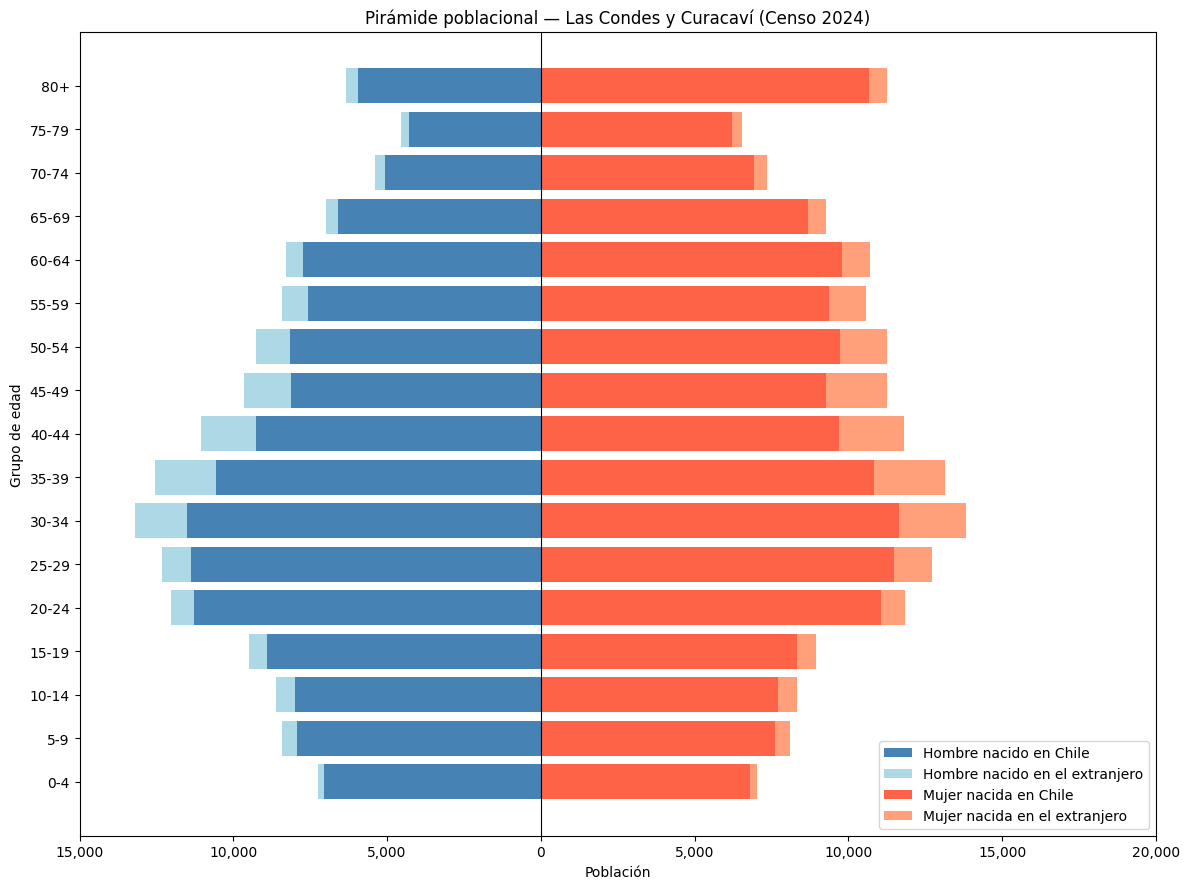

In [6]:
print("=== PARTE 1.1: PIRÁMIDE DE EDAD ===")

# Filtrar edades válidas y grupos de nacimiento válidos
df_piramide = df[
    (df["edad"] != -99) &
    (df["p25_lug_nacimiento_rec"].isin([1, 2]))
].copy()

# Crear grupos de edad de 5 años
bins = list(range(0, 81, 5)) + [200]
labels = [f"{i}-{i+4}" for i in range(0, 80, 5)] + ["80+"]
df_piramide["grupo_edad"] = pd.cut(df_piramide["edad"], bins=bins, labels=labels, right=False)

# Calcular conteos por grupo
hc = df_piramide[(df_piramide["sexo"]==1) & (df_piramide["p25_lug_nacimiento_rec"]==1)]["grupo_edad"].value_counts().reindex(labels, fill_value=0)
he = df_piramide[(df_piramide["sexo"]==1) & (df_piramide["p25_lug_nacimiento_rec"]==2)]["grupo_edad"].value_counts().reindex(labels, fill_value=0)
mc = df_piramide[(df_piramide["sexo"]==2) & (df_piramide["p25_lug_nacimiento_rec"]==1)]["grupo_edad"].value_counts().reindex(labels, fill_value=0)
me = df_piramide[(df_piramide["sexo"]==2) & (df_piramide["p25_lug_nacimiento_rec"]==2)]["grupo_edad"].value_counts().reindex(labels, fill_value=0)

y = np.arange(len(labels))

plt.figure(figsize=(12, 9))
plt.barh(y, -hc, color="steelblue",   label="Hombre nacido en Chile")
plt.barh(y, -he, left=-hc, color="lightblue", label="Hombre nacido en el extranjero")
plt.barh(y,  mc, color="tomato",      label="Mujer nacida en Chile")
plt.barh(y,  me, left=mc, color="lightsalmon", label="Mujer nacida en el extranjero")

plt.yticks(y, labels)
plt.xlabel("Población")
plt.ylabel("Grupo de edad")
plt.title("Pirámide poblacional — Las Condes y Curacaví (Censo 2024)")
plt.axvline(0, color="black", linewidth=0.8)
ticks = plt.xticks()[0]
plt.xticks(ticks, [f"{abs(int(t)):,}" for t in ticks])
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

La estructura demográfica muestra una distribución relativamente equilibrada por sexo, con una leve mayor proporción de mujeres. Se observa una concentración en edades adultas (25-44 años), especialmente en Las Condes, lo que evidencia una población económicamente activa. La población nacida en el extranjero se concentra principalmente en el tramo 25-39 años, patrón típico de migración laboral. Los grupos de edad más jóvenes (0-14) muestran menor presencia relativa, lo que es consistente con una tendencia al envejecimiento poblacional.

### 1.2 Razón de dependencia por comuna

La razón de dependencia mide la proporción de población dependiente (menores de 15 y mayores de 64 años) respecto a la población en edad activa (15-64 años). Un valor de 0.5 significa que por cada 100 personas activas hay 50 dependientes.

**Fórmula:** Dependencia = (Población 0-14 + Población 65+) / Población 15-64

In [7]:
print("=== PARTE 1.2: RAZÓN DE DEPENDENCIA ===")

df_dep = df[df["edad"] != -99].copy()

def clasificar_edad(e):
    if e <= 14:   return "joven"
    elif e <= 64: return "activa"
    else:         return "mayor"

df_dep["grupo_dep"] = df_dep["edad"].apply(clasificar_edad)

tabla_dep = df_dep.groupby(["comuna", "grupo_dep"]).size().unstack(fill_value=0)
tabla_dep["dependency_ratio"] = (tabla_dep["joven"] + tabla_dep["mayor"]) / tabla_dep["activa"]
tabla_dep = tabla_dep.reset_index()
tabla_dep["nombre_comuna"] = tabla_dep["comuna"].map(mapa_comuna)

print(tabla_dep[["nombre_comuna", "joven", "activa", "mayor", "dependency_ratio"]].to_string(index=False))

=== PARTE 1.2: RAZÓN DE DEPENDENCIA ===
nombre_comuna  joven  activa  mayor  dependency_ratio
   Las Condes  41831  200620  53683          0.476094
     Curacaví   6456   23399   5310          0.502842


Curacaví presenta una razón de dependencia ligeramente mayor que Las Condes, lo que indica una mayor proporción de población no activa respecto a la activa. Esto es esperable dado el carácter más rural de Curacaví, donde suele haber mayor presencia de población joven. Ambas comunas presentan valores bajo 0.6, lo que indica una estructura poblacional relativamente joven y activa.

### 1.3 Distribución del tamaño del hogar

Se calcula el número de personas por hogar y se clasifica según la composición de lugar de nacimiento: hogares formados solo por personas nacidas en Chile, solo por nacidos en el extranjero, o hogares mixtos. Esto permite identificar si existe segregación residencial entre la población nativa e inmigrante.

=== PARTE 1.3: TAMAÑO DEL HOGAR ===
tipo_hogar     Mixto  Nacido en Chile  Nacido en el extranjero
tam_hogar_cat                                                 
1                  0            30123                     4098
2               3874            32654                     2283
3               3263            20017                      868
4               2928            14949                      569
5               1511             6227                      213
6                710             2015                       55
7                247              650                       12
8+               194              420                        9



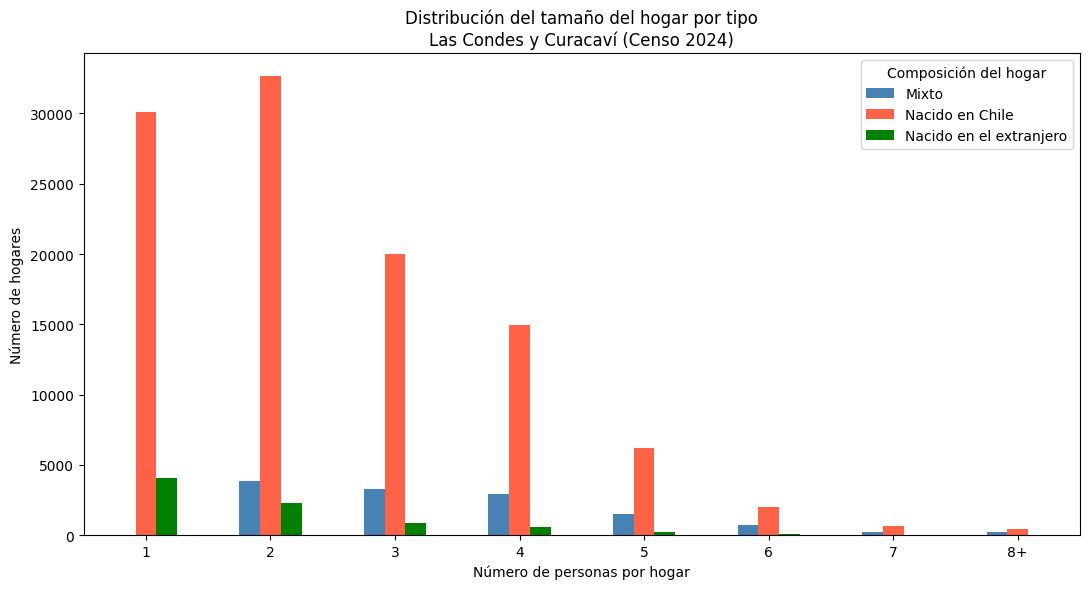

In [8]:
print("=== PARTE 1.3: TAMAÑO DEL HOGAR ===")

df_hog = df[df["p25_lug_nacimiento_rec"].isin([1, 2])].copy()

# Tamaño por hogar
tam_hogar = df_hog.groupby(["id_vivienda", "id_hogar"]).size().reset_index(name="tam_hogar")

# Clasificar tipo de hogar según composición
def clasificar_hogar(x):
    valores = set(x)
    if valores == {1}:   return "Nacido en Chile"
    elif valores == {2}: return "Nacido en el extranjero"
    else:                return "Mixto"

nac_hogar = (
    df_hog.groupby(["id_vivienda", "id_hogar"])["p25_lug_nacimiento_rec"]
    .apply(clasificar_hogar).reset_index(name="tipo_hogar")
)

hogares_resumen = tam_hogar.merge(nac_hogar, on=["id_vivienda", "id_hogar"], how="left")
hogares_resumen["tam_hogar_cat"] = hogares_resumen["tam_hogar"].apply(
    lambda x: "8+" if x >= 8 else str(x)
)

orden_tamano = [str(i) for i in range(1, 8)] + ["8+"]
tabla_hogar = (
    hogares_resumen.groupby(["tam_hogar_cat", "tipo_hogar"])
    .size().unstack(fill_value=0).reindex(orden_tamano, fill_value=0)
)

print(tabla_hogar)
print()

tabla_hogar.plot(kind="bar", figsize=(11, 6), color=["steelblue", "tomato", "green"])
plt.title("Distribución del tamaño del hogar por tipo\nLas Condes y Curacaví (Censo 2024)")
plt.xlabel("Número de personas por hogar")
plt.ylabel("Número de hogares")
plt.xticks(rotation=0)
plt.legend(title="Composición del hogar")
plt.tight_layout()
plt.show()

Predominan los hogares pequeños de 1 a 3 personas, especialmente aquellos formados por personas nacidas en Chile. Los hogares formados exclusivamente por personas nacidas en el extranjero son minoritarios, mientras que los hogares mixtos aparecen principalmente en tamaños intermedios (2-4 personas). Este patrón sugiere que los inmigrantes tienden a integrarse en hogares compartidos con chilenos más que a formar núcleos exclusivamente extranjeros.

### 1.4 Educación y empleo

Se comparan dos indicadores clave por comuna y grupo de nacimiento:

- **Escolaridad promedio:** años de estudio completados para personas de 25 años o más (se excluyen menores porque aún están estudiando y se excluyen los valores -99)
- **Tasa de empleo:** proporción de personas ocupadas (`sit_fuerza_trabajo == 1`) entre la población de 15 a 64 años

=== PARTE 1.4: EDUCACIÓN Y EMPLEO ===
Años promedio de escolaridad (personas de 25 años y más):
grupo_nac      Nacido en Chile  Nacido en el extranjero
nombre_comuna                                          
Curacaví                 11.49                     13.1
Las Condes               15.97                     16.1

Tasa de empleo (personas de 15 a 64 años):
grupo_nac      Nacido en Chile  Nacido en el extranjero
nombre_comuna                                          
Curacaví                0.6038                   0.7032
Las Condes              0.6912                   0.8012


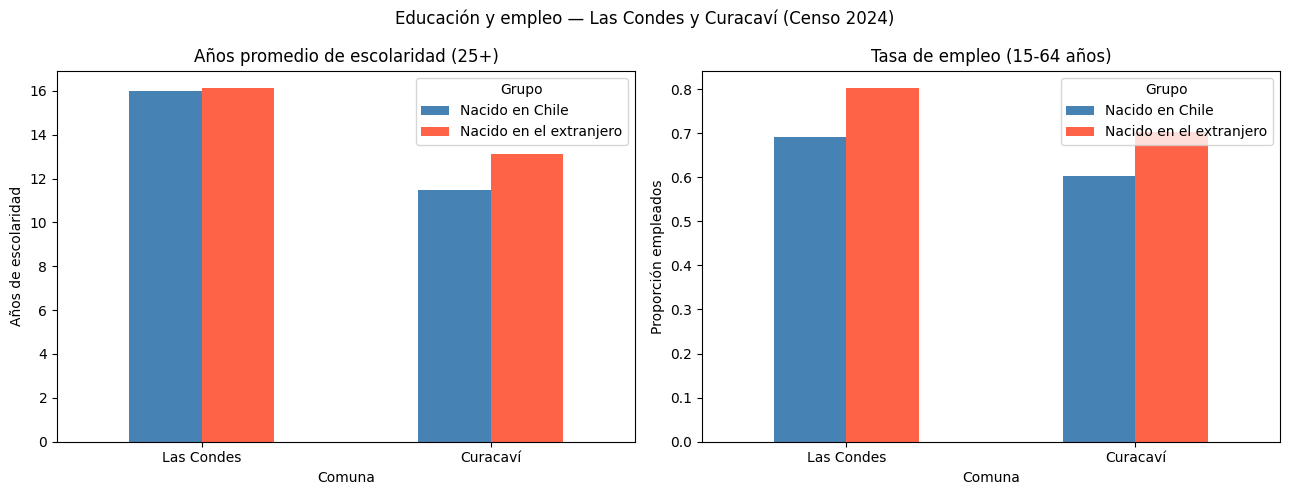

In [9]:
print("=== PARTE 1.4: EDUCACIÓN Y EMPLEO ===")

df_14 = df[df["p25_lug_nacimiento_rec"].isin([1, 2])].copy()
df_14["grupo_nac"] = df_14["p25_lug_nacimiento_rec"].map({1: "Nacido en Chile", 2: "Nacido en el extranjero"})
df_14["nombre_comuna"] = df_14["comuna"].map(mapa_comuna)

# Escolaridad promedio 25+
df_esc = df_14[(df_14["edad"] >= 25) & (df_14["edad"] != -99) & (df_14["escolaridad"] != -99)].copy()
tabla_esc = df_esc.groupby(["nombre_comuna", "grupo_nac"])["escolaridad"].mean().unstack()

print("Años promedio de escolaridad (personas de 25 años y más):")
print(tabla_esc.round(2))

# Tasa de empleo 15-64
df_emp = df_14[
    (df_14["edad"] >= 15) & (df_14["edad"] <= 64) & (df_14["edad"] != -99) &
    (df_14["sit_fuerza_trabajo"].notna()) & (df_14["sit_fuerza_trabajo"] != -99)
].copy()
df_emp["ocupado"] = (df_emp["sit_fuerza_trabajo"] == 1).astype(int)
tabla_emp = df_emp.groupby(["nombre_comuna", "grupo_nac"])["ocupado"].mean().unstack()

print("\nTasa de empleo (personas de 15 a 64 años):")
print(tabla_emp.round(4))

# Gráficos lado a lado
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

orden_comunas = ["Las Condes", "Curacaví"]
orden_nac = ["Nacido en Chile", "Nacido en el extranjero"]

tabla_esc.reindex(index=orden_comunas, columns=orden_nac).plot(
    kind="bar", ax=axes[0], color=["steelblue", "tomato"]
)
axes[0].set_title("Años promedio de escolaridad (25+)")
axes[0].set_xlabel("Comuna")
axes[0].set_ylabel("Años de escolaridad")
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(title="Grupo")

tabla_emp.reindex(index=orden_comunas, columns=orden_nac).plot(
    kind="bar", ax=axes[1], color=["steelblue", "tomato"]
)
axes[1].set_title("Tasa de empleo (15-64 años)")
axes[1].set_xlabel("Comuna")
axes[1].set_ylabel("Proporción empleados")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(title="Grupo")

plt.suptitle("Educación y empleo — Las Condes y Curacaví (Censo 2024)")
plt.tight_layout()
plt.show()

Las Condes presenta niveles significativamente más altos de escolaridad, superando los 15 años en promedio, mientras que Curacaví se sitúa en torno a los 11-13 años. En ambas comunas, las personas nacidas en el extranjero presentan escolaridad promedio igual o ligeramente superior a las nacidas en Chile, lo que sugiere que los inmigrantes que llegan a estas comunas son relativamente calificados.

En términos laborales, la población nacida en el extranjero exhibe mayores tasas de empleo en ambas comunas, especialmente en Las Condes. Esto es consistente con la literatura sobre migración: quienes emigran tienden a ser personas en edad activa con alta motivación laboral.

---
## Parte 2 — Panorama Migratorio

### 2.1 Porcentaje de población nacida en el extranjero por comuna

Se calcula el porcentaje de personas nacidas fuera de Chile para cada una de las comunas asignadas, usando la variable `p25_lug_nacimiento_rec` (1 = Chile, 2 = Extranjero). Se excluyen los valores faltantes del denominador.

=== PARTE 2.1: % NACIDOS EN EL EXTRANJERO POR COMUNA ===
nombre_comuna  pop_total_valida  pop_foreign  pct_foreign
   Las Condes            292739        31069    10.613208
     Curacaví             34977         1460     4.174172


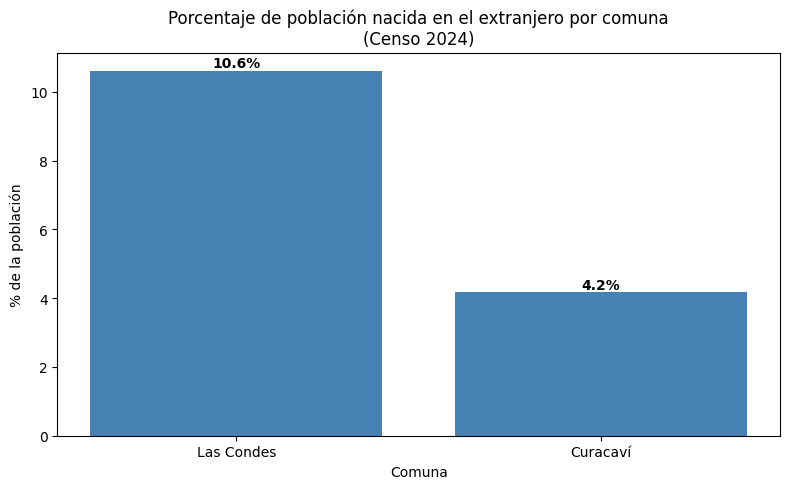

In [10]:
print("=== PARTE 2.1: % NACIDOS EN EL EXTRANJERO POR COMUNA ===")

df_mig = df[df["p25_lug_nacimiento_rec"].isin([1, 2])].copy()
df_mig["nombre_comuna"] = df_mig["comuna"].map(mapa_comuna)

tabla_foreign = (
    df_mig.groupby(["comuna", "nombre_comuna"])
    .agg(
        pop_total_valida=("id_persona", "count"),
        pop_foreign=("p25_lug_nacimiento_rec", lambda x: (x == 2).sum())
    ).reset_index()
)
tabla_foreign["pct_foreign"] = tabla_foreign["pop_foreign"] / tabla_foreign["pop_total_valida"] * 100

print(tabla_foreign[["nombre_comuna", "pop_total_valida", "pop_foreign", "pct_foreign"]].to_string(index=False))

# Gráfico
plt.figure(figsize=(8, 5))
bars = plt.bar(tabla_foreign["nombre_comuna"], tabla_foreign["pct_foreign"], color="steelblue")
plt.title("Porcentaje de población nacida en el extranjero por comuna\n(Censo 2024)")
plt.xlabel("Comuna")
plt.ylabel("% de la población")
for bar, valor in zip(bars, tabla_foreign["pct_foreign"]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, f"{valor:.1f}%", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

Las Condes presenta una proporción de población nacida en el extranjero significativamente mayor que Curacaví (≈10.6% vs ≈4.2%). Esta diferencia refleja el mayor dinamismo económico y la mayor oferta de trabajo calificado en Las Condes, que actúa como polo de atracción para inmigrantes. Curacaví, siendo una comuna más rural y de menor ingreso, atrae una proporción menor de población extranjera.

### 2.2 Top 10 nacionalidades de la población extranjera

Se identifican las 10 principales nacionalidades entre las personas nacidas en el extranjero, usando la variable `p27_nacionalidad_esp` que contiene el código específico del país. Se excluyen los registros con nacionalidad chilena (código 152), que corresponden a chilenos nacidos en el extranjero que posteriormente obtuvieron o ya tenían nacionalidad chilena.

=== PARTE 2.2: TOP 10 NACIONALIDADES ===
          nacionalidad  cantidad
     América del Norte       498
               Bolivia       578
América Central/Caribe      1147
                  Asia      1745
              Colombia      2259
 Otros América del Sur      2505
                Europa      2750
                  Perú      3165
             Argentina      3700
             Venezuela      6020


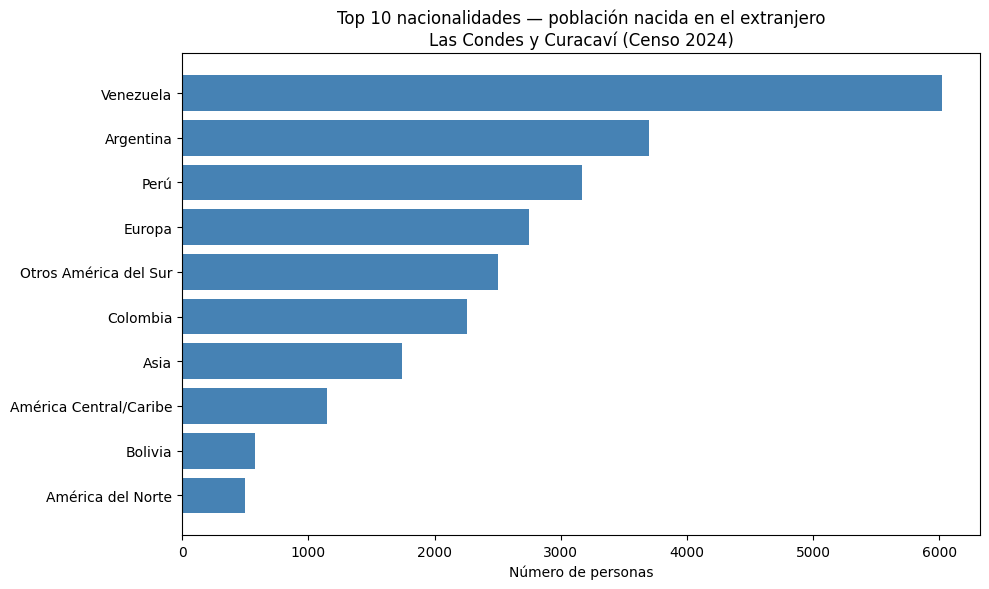

In [11]:
print("=== PARTE 2.2: TOP 10 NACIONALIDADES ===")

df_ext = df[
    (df["p25_lug_nacimiento_rec"] == 2) &
    (df["p27_nacionalidad_esp"].notna()) &
    (df["p27_nacionalidad_esp"] != 152)   # excluir chilenos nacidos en el extranjero
].copy()

top_nac = df_ext["p27_nacionalidad_esp"].value_counts().head(10).reset_index()
top_nac.columns = ["codigo", "cantidad"]

# Mapeo de códigos a nombres de países (fuente: diccionario cod_territoriales_especificos)
mapa_nacionalidad = {
    862: "Venezuela", 32: "Argentina", 604: "Perú",
    150: "Europa", 5: "Otros América del Sur", 170: "Colombia",
    142: "Asia", 13: "América Central/Caribe", 68: "Bolivia",
    21: "América del Norte", 332: "Haití", 9: "Oceanía", 2: "África"
}
top_nac["nacionalidad"] = top_nac["codigo"].map(mapa_nacionalidad).fillna(top_nac["codigo"].astype(str))
top_nac = top_nac.sort_values("cantidad", ascending=True)

print(top_nac[["nacionalidad", "cantidad"]].to_string(index=False))

# Gráfico
plt.figure(figsize=(10, 6))
plt.barh(top_nac["nacionalidad"], top_nac["cantidad"], color="steelblue")
plt.title("Top 10 nacionalidades — población nacida en el extranjero\nLas Condes y Curacaví (Censo 2024)")
plt.xlabel("Número de personas")
plt.tight_layout()
plt.show()

Venezuela lidera ampliamente el ranking de nacionalidades extranjeras, seguida por Argentina y Perú. Esta distribución refleja los patrones migratorios recientes de Chile: el flujo venezolano se intensificó a partir de 2017 debido a la crisis política y económica en ese país, mientras que la presencia argentina y peruana tiene una historia más larga. La presencia de categorías como "Europa" y "Asia" sugiere también una diversificación de los orígenes migratorios en comunas de alto ingreso como Las Condes.

Cabe señalar que se identificaron registros de personas nacidas en el extranjero con nacionalidad chilena, lo que se explica por procesos de naturalización o por chilenos nacidos fuera del país. Estos casos fueron excluidos del ranking.

### 2.3 Residencia hace 5 años

La variable `p24_lug_resid5` indica dónde vivía la persona en abril de 2019 (5 años antes del Censo 2024). Permite medir la movilidad territorial reciente: qué proporción de la población se ha mantenido en la misma comuna, proviene de otra comuna o llegó desde otro país.

Se excluyen menores de 5 años (que no habían nacido en 2019) y los valores faltantes (-99).

=== PARTE 2.3: LUGAR DE RESIDENCIA HACE 5 AÑOS ===
Distribución porcentual por comuna:
categoria_resid5  Misma comuna  Otra comuna, misma región  Otra región
nombre_comuna                                                         
Curacaví                  84.3                       13.9          1.7
Las Condes                75.1                       21.5          3.5


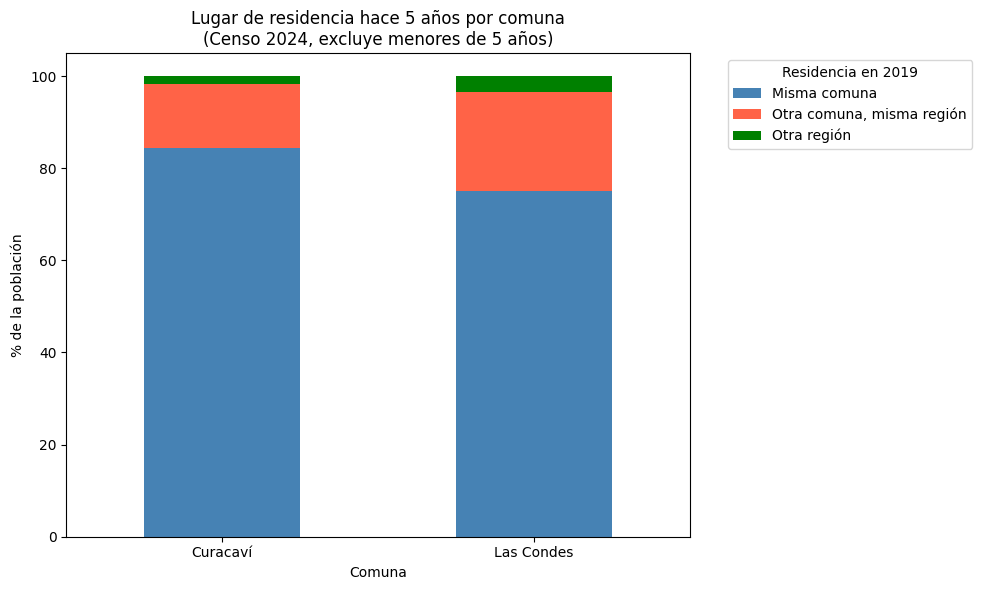

In [12]:
print("=== PARTE 2.3: LUGAR DE RESIDENCIA HACE 5 AÑOS ===")

df_res5 = df[
    (df["edad"] >= 5) & (df["edad"] != -99) &
    (df["p24_lug_resid5"] != -99) & (df["p24_lug_resid5"] != 1)  # excluir "aún no nacía"
].copy()

mapa_resid5 = {
    2: "Misma comuna",
    3: "Otra comuna, misma región",
    4: "Otra región",
    5: "Otro país"
}
df_res5["categoria_resid5"] = df_res5["p24_lug_resid5"].map(mapa_resid5)
df_res5 = df_res5[df_res5["categoria_resid5"].notna()].copy()

tabla_res5 = df_res5.groupby(["nombre_comuna", "categoria_resid5"]).size().unstack(fill_value=0)
tabla_res5_pct = tabla_res5.div(tabla_res5.sum(axis=1), axis=0) * 100

print("Distribución porcentual por comuna:")
print(tabla_res5_pct.round(1))

# Gráfico de barras apiladas
orden_cat = ["Misma comuna", "Otra comuna, misma región", "Otra región", "Otro país"]
tabla_res5_pct = tabla_res5_pct.reindex(columns=[c for c in orden_cat if c in tabla_res5_pct.columns])

tabla_res5_pct.plot(kind="bar", stacked=True, figsize=(10, 6),
                    color=["steelblue", "tomato", "green", "orange"])
plt.title("Lugar de residencia hace 5 años por comuna\n(Censo 2024, excluye menores de 5 años)")
plt.xlabel("Comuna")
plt.ylabel("% de la población")
plt.xticks(rotation=0)
plt.legend(title="Residencia en 2019", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

La mayoría de la población en ambas comunas vivía en la misma comuna hace 5 años, evidenciando alta estabilidad territorial. Sin embargo, Las Condes presenta una mayor proporción de personas provenientes de otras comunas de la misma región y de otros países, lo que es consistente con su carácter más dinámico y cosmopolita. Curacaví muestra una estructura más estable y con menor movilidad, reflejo de su carácter más rural y de menor atracción migratoria.

### 2.4 Período de llegada de inmigrantes

La variable `p26_llegada_periodo` registra en qué período llegó a Chile la persona nacida en el extranjero. Permite identificar si la inmigración es un fenómeno reciente o tiene historia más larga en las comunas analizadas.

=== PARTE 2.4: PERÍODO DE LLEGADA DE INMIGRANTES ===
periodo
Antes 1990    2848
1990-1999     3897
2000-2009     6999
2010-2014     4333
2015-2016     3079
2017-2018     4863
2019-2020     2757
2021-2024     3590
Name: count, dtype: int64


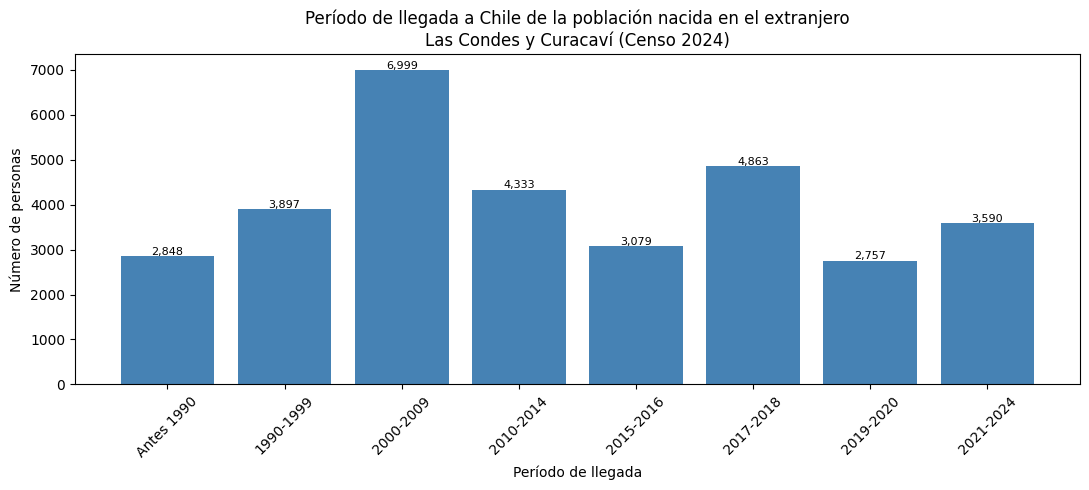

In [13]:
print("=== PARTE 2.4: PERÍODO DE LLEGADA DE INMIGRANTES ===")

df_llegada = df[
    (df["p25_lug_nacimiento_rec"] == 2) &
    (df["p26_llegada_periodo"].notna()) &
    (df["p26_llegada_periodo"] != -99)
].copy()

mapa_llegada = {
    1: "Antes 1990", 2: "1990-1999", 3: "2000-2009",
    4: "2010-2014", 5: "2015-2016", 6: "2017-2018",
    7: "2019-2020", 8: "2021-2024"
}
df_llegada["periodo"] = df_llegada["p26_llegada_periodo"].map(mapa_llegada)

orden_periodos = list(mapa_llegada.values())
tabla_llegada = df_llegada["periodo"].value_counts().reindex(orden_periodos)

print(tabla_llegada)

# Gráfico
fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(tabla_llegada.index, tabla_llegada.values, color="steelblue")
ax.set_title("Período de llegada a Chile de la población nacida en el extranjero\nLas Condes y Curacaví (Censo 2024)")
ax.set_xlabel("Período de llegada")
ax.set_ylabel("Número de personas")
ax.tick_params(axis="x", rotation=45)
for bar, valor in zip(bars, tabla_llegada.values):
    if not np.isnan(valor):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                f"{int(valor):,}", ha="center", fontsize=8)
plt.tight_layout()
plt.show()

El período 2017-2018 concentra el mayor flujo de llegada de inmigrantes, lo que coincide con la intensificación de la crisis política y económica en Venezuela. Se observa un segundo peak en 2000-2009, relacionado con los flujos peruanos y bolivianos de esa época. Tras la pandemia (2019-2020 y 2021-2024) se observa una leve disminución, aunque los flujos se mantienen relevantes. En conjunto, la inmigración en estas comunas es un fenómeno predominantemente reciente, concentrado en los últimos 15 años.

---
## Parte 3 — Visualización Espacial

### 3.1 y 3.2 Mapas coropléticos

Se generan dos mapas coropléticos usando el shapefile oficial de comunas de Chile (fuente: Biblioteca del Congreso Nacional):

1. **Mapa 1:** Población total por comuna
2. **Mapa 2:** Porcentaje de población nacida en el extranjero por comuna

Los mapas permiten visualizar espacialmente las diferencias entre Las Condes y Curacaví.

In [14]:
import zipfile
import os
import geopandas as gpd

# Extraer shapefile si no existe
os.makedirs("materials/shapefiles", exist_ok=True)
if not os.path.exists("materials/shapefiles/comunas.shp"):
    with zipfile.ZipFile("Comunas.zip") as z:
        z.extractall("materials/shapefiles/")
        print("Shapefile extraído.")

# Cargar shapefile
comunas_gdf = gpd.read_file("materials/shapefiles/comunas.shp")
print(f"Shapefile cargado: {len(comunas_gdf)} comunas")
print(f"Columnas: {comunas_gdf.columns.tolist()}")

Shapefile extraído.
Shapefile cargado: 346 comunas
Columnas: ['objectid', 'shape_leng', 'dis_elec', 'cir_sena', 'cod_comuna', 'codregion', 'st_area_sh', 'st_length_', 'Region', 'Comuna', 'Provincia', 'geometry']


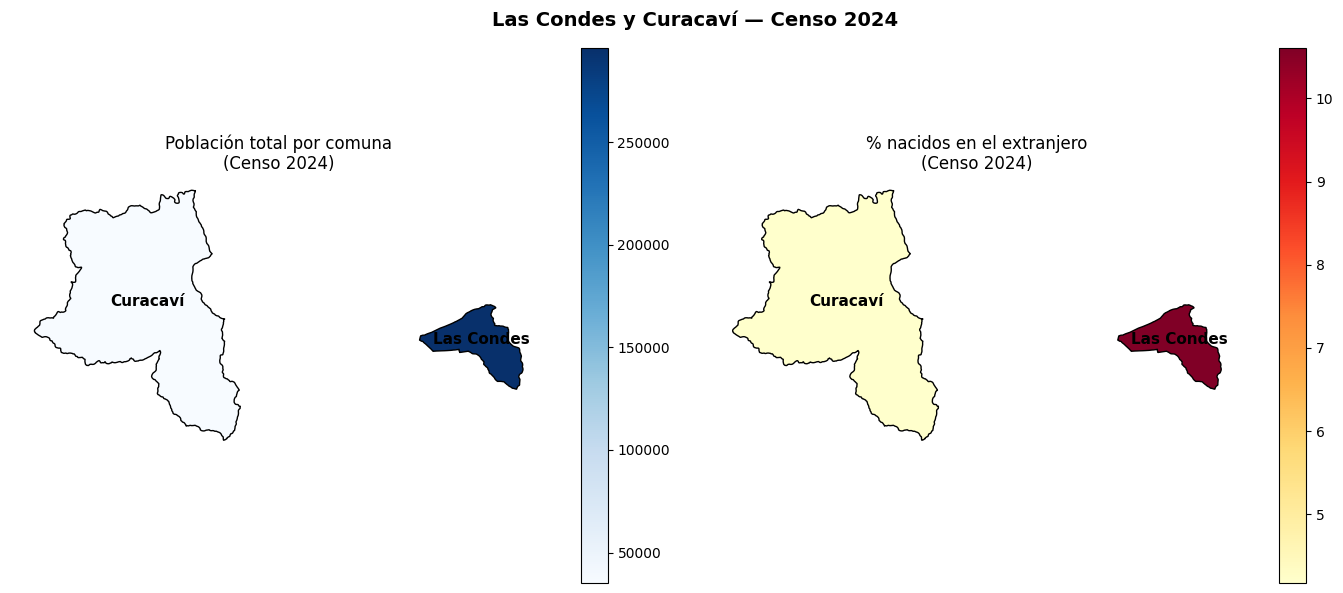

In [15]:
# Calcular indicadores por comuna
resumen_mapa = df.groupby("comuna").agg(pop_total=("id_persona", "count")).reset_index()
resumen_mapa["pct_foreign"] = (
    df[df["p25_lug_nacimiento_rec"].isin([1,2])]
    .groupby("comuna")
    .apply(lambda x: (x["p25_lug_nacimiento_rec"]==2).sum() / len(x) * 100, include_groups=False)
    .values
)
resumen_mapa["nombre_comuna"] = resumen_mapa["comuna"].map(mapa_comuna)

# Filtrar geodataframe a nuestras dos comunas y hacer merge
mis_comunas_gdf = comunas_gdf[comunas_gdf["cod_comuna"].isin([13114, 13503])].copy()
mis_comunas_gdf = mis_comunas_gdf.merge(resumen_mapa, left_on="cod_comuna", right_on="comuna", how="left")

# Graficar
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

mis_comunas_gdf.plot(column="pop_total", ax=axes[0], legend=True,
                      cmap="Blues", edgecolor="black")
for _, row in mis_comunas_gdf.iterrows():
    axes[0].annotate(row["Comuna"], xy=row["geometry"].centroid.coords[0],
                     ha="center", fontsize=11, fontweight="bold")
axes[0].set_title("Población total por comuna\n(Censo 2024)")
axes[0].axis("off")

mis_comunas_gdf.plot(column="pct_foreign", ax=axes[1], legend=True,
                      cmap="YlOrRd", edgecolor="black")
for _, row in mis_comunas_gdf.iterrows():
    axes[1].annotate(row["Comuna"], xy=row["geometry"].centroid.coords[0],
                     ha="center", fontsize=11, fontweight="bold")
axes[1].set_title("% nacidos en el extranjero\n(Censo 2024)")
axes[1].axis("off")

plt.suptitle("Las Condes y Curacaví — Censo 2024", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

Los mapas refuerzan visualmente las diferencias observadas en el análisis. Las Condes concentra una población significativamente mayor y una mayor proporción de personas nacidas en el extranjero. La diferencia de escala entre ambas comunas queda claramente representada en el mapa de población total. El mapa de % extranjeros muestra en escala de color la mayor concentración migratoria en Las Condes respecto a Curacaví.

---
## Parte 4 — Tabla Resumen Comunal

Esta tabla concentra los principales indicadores demográficos y migratorios calculados a lo largo del notebook, agregados por comuna. Será reutilizada en la **Tarea 3** para el análisis ecológico cross-dataset.

Los indicadores calculados son:
- Población total, chilena y extranjera
- % extranjeros
- Edad mediana (chilenos vs extranjeros)
- Escolaridad promedio para personas de 25 años o más (chilenos vs extranjeros)
- Tasa de empleo para personas de 15 a 64 años (chilenos vs extranjeros)
- Razón de dependencia general

> **Importante:** Los valores `-99` son tratados como datos faltantes y excluidos de todos los cálculos.

In [17]:
print("=== PARTE 4: TABLA RESUMEN COMUNAL ===")

def build_summary(grupo):
    g = grupo[grupo["p25_lug_nacimiento_rec"].isin([1, 2])].copy()
    pop_total   = len(g)
    pop_chilean = (g["p25_lug_nacimiento_rec"] == 1).sum()
    pop_foreign = (g["p25_lug_nacimiento_rec"] == 2).sum()
    pct_foreign = pop_foreign / pop_total if pop_total > 0 else np.nan

    g_edad = g[g["edad"] != -99]
    median_age_chilean = g_edad.loc[g_edad["p25_lug_nacimiento_rec"]==1, "edad"].median()
    median_age_foreign = g_edad.loc[g_edad["p25_lug_nacimiento_rec"]==2, "edad"].median()

    g_esc = g[(g["edad"] >= 25) & (g["edad"] != -99) & (g["escolaridad"] != -99)]
    mean_schooling_chilean = g_esc.loc[g_esc["p25_lug_nacimiento_rec"]==1, "escolaridad"].mean()
    mean_schooling_foreign = g_esc.loc[g_esc["p25_lug_nacimiento_rec"]==2, "escolaridad"].mean()

    g_emp = g[
        (g["edad"]>=15) & (g["edad"]<=64) & (g["edad"]!=-99) &
        (g["sit_fuerza_trabajo"].notna()) & (g["sit_fuerza_trabajo"]!=-99)
    ].copy()
    g_emp["ocupado"] = (g_emp["sit_fuerza_trabajo"] == 1).astype(int)
    emp_rate_chilean = g_emp.loc[g_emp["p25_lug_nacimiento_rec"]==1, "ocupado"].mean()
    emp_rate_foreign = g_emp.loc[g_emp["p25_lug_nacimiento_rec"]==2, "ocupado"].mean()

    g_dep = g[g["edad"] != -99]
    joven  = (g_dep["edad"] <= 14).sum()
    activa = ((g_dep["edad"] >= 15) & (g_dep["edad"] <= 64)).sum()
    mayor  = (g_dep["edad"] >= 65).sum()
    dependency_ratio = (joven + mayor) / activa if activa > 0 else np.nan

    codigo = int(grupo.name)
    return pd.Series({
        "codigo_comuna": codigo,
        "nombre_comuna": mapa_comuna.get(codigo, str(codigo)),
        "pop_total": pop_total,
        "pop_chilean": int(pop_chilean),
        "pop_foreign": int(pop_foreign),
        "pct_foreign": round(pct_foreign, 4),
        "median_age_chilean": median_age_chilean,
        "median_age_foreign": median_age_foreign,
        "mean_schooling_chilean": round(mean_schooling_chilean, 2),
        "mean_schooling_foreign": round(mean_schooling_foreign, 2),
        "emp_rate_chilean": round(emp_rate_chilean, 4),
        "emp_rate_foreign": round(emp_rate_foreign, 4),
        "dependency_ratio": round(dependency_ratio, 4)
    })

summary = df.groupby("comuna").apply(build_summary, include_groups=False).reset_index(drop=True)

print("\nTabla resumen comunal:")
print(summary.to_string(index=False))

# Guardar como CSV
os.makedirs("output", exist_ok=True)
summary.to_csv("output/tarea1_comuna_summary.csv", index=False)
print("\nArchivo guardado en: output/tarea1_comuna_summary.csv")

=== PARTE 4: TABLA RESUMEN COMUNAL ===

Tabla resumen comunal:
 codigo_comuna nombre_comuna  pop_total  pop_chilean  pop_foreign  pct_foreign  median_age_chilean  median_age_foreign  mean_schooling_chilean  mean_schooling_foreign  emp_rate_chilean  emp_rate_foreign  dependency_ratio
         13114    Las Condes     292739       261670        31069       0.1061                38.0                40.0                   15.97                    16.1            0.6912            0.8012            0.4712
         13503      Curacaví      34977        33517         1460       0.0417                38.0                35.0                   11.49                    13.1            0.6038            0.7032            0.5032

Archivo guardado en: output/tarea1_comuna_summary.csv


**Interpretación de la tabla resumen:** Las diferencias estructurales entre ambas comunas quedan claramente reflejadas en los indicadores:

- **Las Condes** tiene mayor población, mayor % extranjero, mayor escolaridad y mayor tasa de empleo tanto en chilenos como extranjeros
- **Curacaví** presenta mayor razón de dependencia y menor escolaridad, consistente con su perfil más rural
- En **ambas comunas**, los inmigrantes tienen mayor escolaridad y mayor tasa de empleo que los nacidos en Chile, patrón típico de migración selectiva

Esta tabla será el insumo principal para el análisis de regresión ecológica en la Tarea 3.

---
## Conclusiones

El análisis demográfico y migratorio de Las Condes y Curacaví evidencia diferencias estructurales claras entre una comuna urbana de alto ingreso y una comuna más periférica y rural.

**Las Condes** se caracteriza por:
- Mayor población total y mayor concentración de inmigrantes (~10.6%)
- Alta escolaridad en toda la población
- Alta tasa de empleo, especialmente en población extranjera
- Mayor movilidad territorial: más personas llegadas desde otras comunas y otros países

**Curacaví** se caracteriza por:
- Menor presencia de población extranjera (~4.2%)
- Mayor razón de dependencia
- Menor escolaridad promedio, especialmente en población chilena
- Mayor estabilidad territorial: la mayoría lleva más de 5 años viviendo en la misma comuna

**En ambas comunas**, la población migrante muestra patrones consistentes: mayor escolaridad relativa, mayor tasa de empleo y llegada predominantemente reciente (desde 2000 en adelante), con un peak notable en 2017-2018 asociado a la crisis venezolana. Las nacionalidades dominantes son Venezuela, Argentina y Perú, reflejo de los flujos migratorios regionales que caracterizan a Chile en las últimas décadas.

In [19]:
# Revisión final
print("=" * 60)
print("REVISIÓN FINAL DEL NOTEBOOK")
print("=" * 60)
print(f"Shape final de df:      {df.shape}")
print(f"Comunas procesadas:     {df['nombre_comuna'].unique()}")
print(f"Total personas:         {len(df):,}")
print(f"\nTabla resumen generada:")
print(summary[["nombre_comuna", "pop_total", "pct_foreign", "dependency_ratio"]].to_string(index=False))

REVISIÓN FINAL DEL NOTEBOOK
Shape final de df:      (331299, 26)
Comunas procesadas:     ['Curacaví' 'Las Condes']
Total personas:         331,299

Tabla resumen generada:
nombre_comuna  pop_total  pct_foreign  dependency_ratio
   Las Condes     292739       0.1061            0.4712
     Curacaví      34977       0.0417            0.5032
